### Chuẩn bị dữ liệu và Môi trường

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu
df = pd.read_csv('../data/temporal/time-series-19-covid-combined.csv')

# Thông tin cơ bản ban đầu
print("Thông tin kiểu dữ liệu ban đầu:")
print(df.info())
print("\n5 dòng đầu tiên:")
display(df.head())

Thông tin kiểu dữ liệu ban đầu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72090 entries, 0 to 72089
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            72090 non-null  object 
 1   Country/Region  72090 non-null  object 
 2   Province/State  21870 non-null  object 
 3   Lat             72090 non-null  float64
 4   Long            72090 non-null  float64
 5   Confirmed       72090 non-null  int64  
 6   Recovered       68310 non-null  float64
 7   Deaths          72090 non-null  int64  
dtypes: float64(3), int64(2), object(3)
memory usage: 4.4+ MB
None

5 dòng đầu tiên:


,Date,Country/Region,Province/State,Lat,Long,Confirmed,Recovered,Deaths
0,2020-01-22,Afghanistan,NaN,33.93911,67.709953,0,0.0,0
1,2020-01-23,Afghanistan,NaN,33.93911,67.709953,0,0.0,0
2,2020-01-24,Afghanistan,NaN,33.93911,67.709953,0,0.0,0
3,2020-01-25,Afghanistan,NaN,33.93911,67.709953,0,0.0,0
4,2020-01-26,Afghanistan,NaN,33.93911,67.709953,0,0.0,0


### Parsing Date and Time

In [ ]:
# Chuyển đổi cột 'Date' từ kiểu string (object) sang datetime64
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Kiểm tra xem có giá trị nào không chuyển đổi được (NaT) không
print(f"Số lượng giá trị không thể parse: {df['Date'].isna().sum()}")

Số lượng giá trị không thể parse: 0


In [ ]:
# Trích xuất các thành phần: Năm, Tháng, Ngày, Thứ trong tuần
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.day_name() # Tên thứ (Monday, Tuesday...)
df['IsWeekend'] = df['Date'].dt.dayofweek // 5 # 1 nếu là cuối tuần, 0 nếu không

print("Dữ liệu sau khi trích xuất thành phần:")
display(df[['Date', 'Year', 'Month', 'Day', 'DayOfWeek']].head())

Dữ liệu sau khi trích xuất thành phần:


,Date,Year,Month,Day,DayOfWeek
0,2020-01-22,2020,1,22,Wednesday
1,2020-01-23,2020,1,23,Thursday
2,2020-01-24,2020,1,24,Friday
3,2020-01-25,2020,1,25,Saturday
4,2020-01-26,2020,1,26,Sunday


In [4]:
# 3. Đặt 'Date' làm Index (quan trọng cho các thao tác time-series sau này)
# Trước khi đặt index, thường ta sẽ group theo Date nếu dữ liệu có nhiều quốc gia
# Ở đây ta demo việc đặt index cho toàn bộ dataframe
df_indexed = df.set_index('Date').sort_index()

print("\nDataframe sau khi thiết lập Datetime Index:")
display(df_indexed.head())


Dataframe sau khi thiết lập Datetime Index:


,Country/Region,Province/State,Lat,Long,Confirmed,Recovered,Deaths,Year,Month,Day,DayOfWeek,IsWeekend
Date,,,,,,,,,,,,
2020-01-22,Afghanistan,NaN,33.939110,67.709953,0,0.0,0,2020,1,22,Wednesday,0
2020-01-22,Canada,Prince Edward Island,46.510700,-63.416800,0,NaN,0,2020,1,22,Wednesday,0
2020-01-22,Seychelles,NaN,-4.679600,55.492000,0,0.0,0,2020,1,22,Wednesday,0
2020-01-22,Canada,Ontario,51.253800,-85.323200,0,NaN,0,2020,1,22,Wednesday,0
2020-01-22,Sierra Leone,NaN,8.460555,-11.779889,0,0.0,0,2020,1,22,Wednesday,0


### Handling Time Gaps

In [5]:
# Chọn 1 quốc gia để demo cho rõ ràng
country_df = df[df['Country/Region'] == 'Afghanistan'].copy()
country_df = country_df.set_index('Date').sort_index()

# Chỉ lấy cột 'Confirmed' để xử lý
ts_data = country_df['Confirmed'].resample('D').first() # Đảm bảo có đủ các ngày

# Giả lập tạo lỗ hổng: Xóa dữ liệu trong 10 ngày giữa chừng
missing_mask = (ts_data.index > '2020-03-01') & (ts_data.index < '2020-03-15')
ts_with_gaps = ts_data.copy()
ts_with_gaps[missing_mask] = np.nan

print(f"Số lượng giá trị thiếu sau khi giả lập: {ts_with_gaps.isna().sum()}")

Số lượng giá trị thiếu sau khi giả lập: 13


In [6]:
# 1. Forward Fill: Lấy giá trị ngày trước đó điền vào
ffill = ts_with_gaps.ffill()

# 2. Backward Fill: Lấy giá trị ngày sau đó điền ngược lại
bfill = ts_with_gaps.bfill()

# 3. Linear Interpolation: Nội suy tuyến tính (đường thẳng)
linear = ts_with_gaps.interpolate(method='linear')

# 4. Polynomial Interpolation: Nội suy đa thức (bậc 2)
poly = ts_with_gaps.interpolate(method='polynomial', order=2)

# 5. Spline Interpolation: Nội suy đường cong Spline
spline = ts_with_gaps.interpolate(method='spline', order=2)

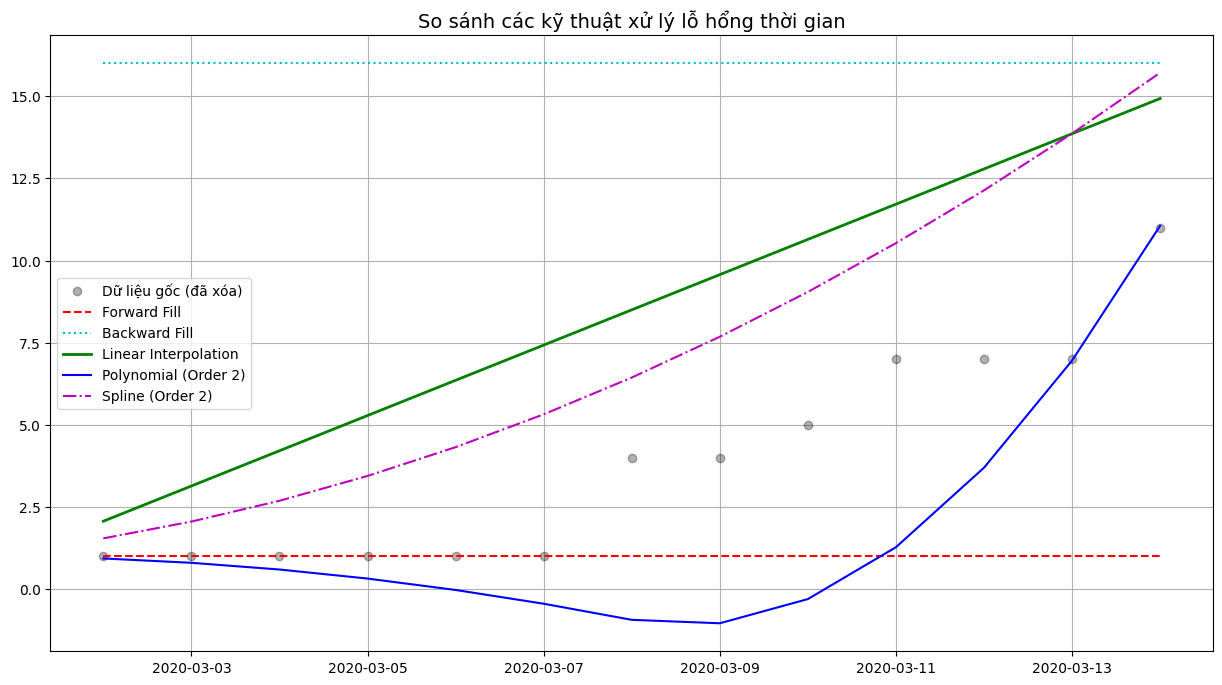

In [7]:
plt.figure(figsize=(15, 8))
plt.plot(ts_data[missing_mask].index, ts_data[missing_mask], 'ko', label='Dữ liệu gốc (đã xóa)', alpha=0.3)

plt.plot(ffill[missing_mask], 'r--', label='Forward Fill')
plt.plot(bfill[missing_mask], 'c:', label='Backward Fill') # Thêm dòng này
plt.plot(linear[missing_mask], 'g-', label='Linear Interpolation', linewidth=2)
plt.plot(poly[missing_mask], 'b-', label='Polynomial (Order 2)')
plt.plot(spline[missing_mask], 'm-.', label='Spline (Order 2)')

plt.title("So sánh các kỹ thuật xử lý lỗ hổng thời gian", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

### Extracting Time-Based Features

In [ ]:
# Trích xuất Thứ, Tháng, Mùa
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek # 0=Monday, 6=Sunday

# Định nghĩa mùa (Bắc bán cầu)
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

df['Season'] = df['Month'].apply(get_season)

# 2. Tạo biến chỉ báo (Indicator variables)
df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

# Ví dụ một số ngày lễ quan trọng (có thể mở rộng thêm)
holidays = ['2020-01-01', '2020-12-25'] 
df['IsHoliday'] = df['Date'].dt.strftime('%Y-%m-%d').isin(holidays).astype(int)

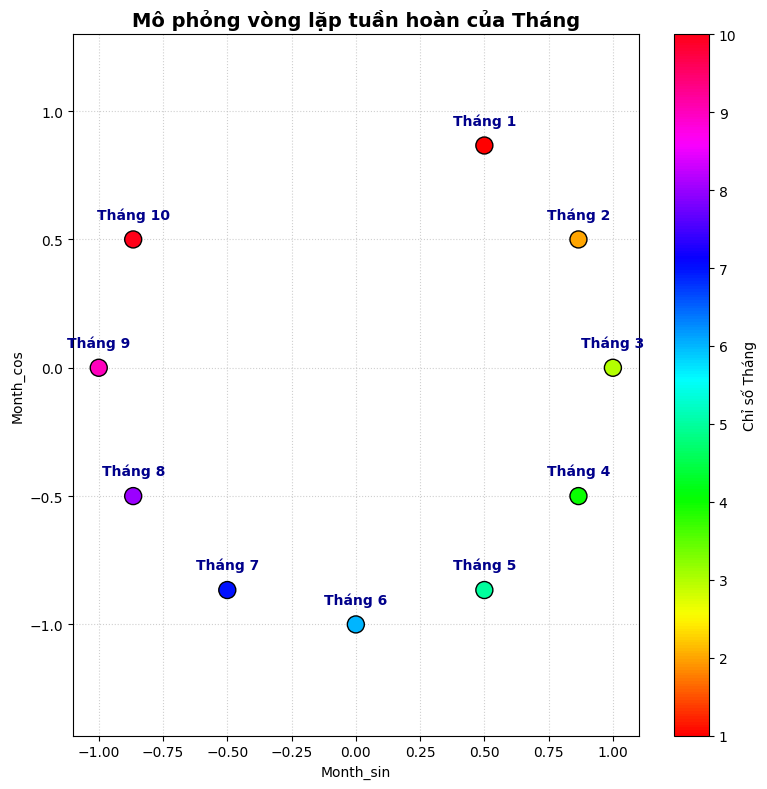

In [10]:
# 1. Định nghĩa lại hàm (để đảm bảo hàm đã tồn tại)
def encode_cyclical(data, col, max_val):
    data[col + '_sin'] = np.sin(2 * np.pi * data[col] / max_val)
    data[col + '_cos'] = np.cos(2 * np.pi * data[col] / max_val)
    return data

# 2. Tạo lại các cột đặc trưng chu kỳ cho df
# Phải đảm bảo df đã có cột 'Month' (đã làm ở bước 4.2)
df = encode_cyclical(df, 'Month', 12)

# 3. Lọc ra danh sách các tháng duy nhất để vẽ nhãn
unique_months = df[['Month', 'Month_sin', 'Month_cos']].drop_duplicates().sort_values('Month')

# 4. Vẽ biểu đồ
plt.figure(figsize=(8, 8))

# Vẽ các điểm
scatter = plt.scatter(unique_months['Month_sin'], unique_months['Month_cos'], 
                      c=unique_months['Month'], cmap='hsv', s=150, edgecolors='black', zorder=3)

# Thêm nhãn "Tháng X" cho từng điểm
for i, row in unique_months.iterrows():
    plt.annotate(f"Tháng {int(row['Month'])}", 
                 (row['Month_sin'], row['Month_cos']),
                 textcoords="offset points", 
                 xytext=(0, 15), # Đẩy nhãn lên cao một chút (15pt)
                 ha='center', 
                 fontsize=10, 
                 fontweight='bold',
                 color='darkblue')

plt.colorbar(scatter, label='Chỉ số Tháng')
plt.title("Mô phỏng vòng lặp tuần hoàn của Tháng", fontsize=14, fontweight='bold')
plt.xlabel("Month_sin")
plt.ylabel("Month_cos")
plt.grid(True, linestyle=':', alpha=0.6)
plt.axis('equal') # Giữ hình tròn không bị méo
plt.tight_layout()
plt.show()

In [11]:
# Tính số ngày kể từ ca nhiễm đầu tiên của mỗi quốc gia
df['DaysSinceStart'] = df.groupby('Country/Region')['Date'].transform(lambda x: (x - x.min()).dt.days)

display(df[['Date', 'Country/Region', 'Month_sin', 'Month_cos', 'DaysSinceStart']].head())

,Date,Country/Region,Month_sin,Month_cos,DaysSinceStart
0,2020-01-22,Afghanistan,0.5,0.866025,0
1,2020-01-23,Afghanistan,0.5,0.866025,1
2,2020-01-24,Afghanistan,0.5,0.866025,2
3,2020-01-25,Afghanistan,0.5,0.866025,3
4,2020-01-26,Afghanistan,0.5,0.866025,4


### Resampling Time Series Data

In [ ]:
# Tính tổng số ca toàn cầu theo từng ngày
global_daily = df.groupby('Date')[['Confirmed', 'Deaths']].sum()

# 1. Downsampling: Chuyển từ Ngày -> Tuần (W) và Tháng (M)
# Sử dụng 'max' vì đây là số liệu tích lũy (Cumulative)
global_weekly = global_daily.resample('W').max()
global_monthly = global_daily.resample('M').max()

# 2. Thử nghiệm các hàm gom cụm khác nhau (Mean vs Sum vs Max)
# Với số liệu tích lũy, 'max' hoặc 'last' là chính xác nhất
weekly_mean = global_daily['Confirmed'].resample('W').mean()
weekly_max = global_daily['Confirmed'].resample('W').max()

print("Kích thước dữ liệu sau khi Resampling:")
print(f"Daily: {len(global_daily)} dòng")
print(f"Weekly: {len(global_weekly)} dòng")
print(f"Monthly: {len(global_monthly)} dòng")

Kích thước dữ liệu sau khi Resampling:
Daily: 270 dòng
Weekly: 39 dòng
Monthly: 10 dòng


C:\Users\QUANG THINH\AppData\Local\Temp\ipykernel_20592\1334629715.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  global_monthly = global_daily.resample('M').max()


In [13]:
# 3. Upsampling: Từ 1 Ngày -> 12 Giờ (12H)
global_12h = global_daily[['Confirmed']].resample('12H').interpolate(method='linear')

display(global_12h.head(5))

C:\Users\QUANG THINH\AppData\Local\Temp\ipykernel_20592\3902771494.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  global_12h = global_daily[['Confirmed']].resample('12H').interpolate(method='linear')


,Confirmed
Date,
2020-01-22 00:00:00,555.0
2020-01-22 12:00:00,604.5
2020-01-23 00:00:00,654.0
2020-01-23 12:00:00,797.5
2020-01-24 00:00:00,941.0


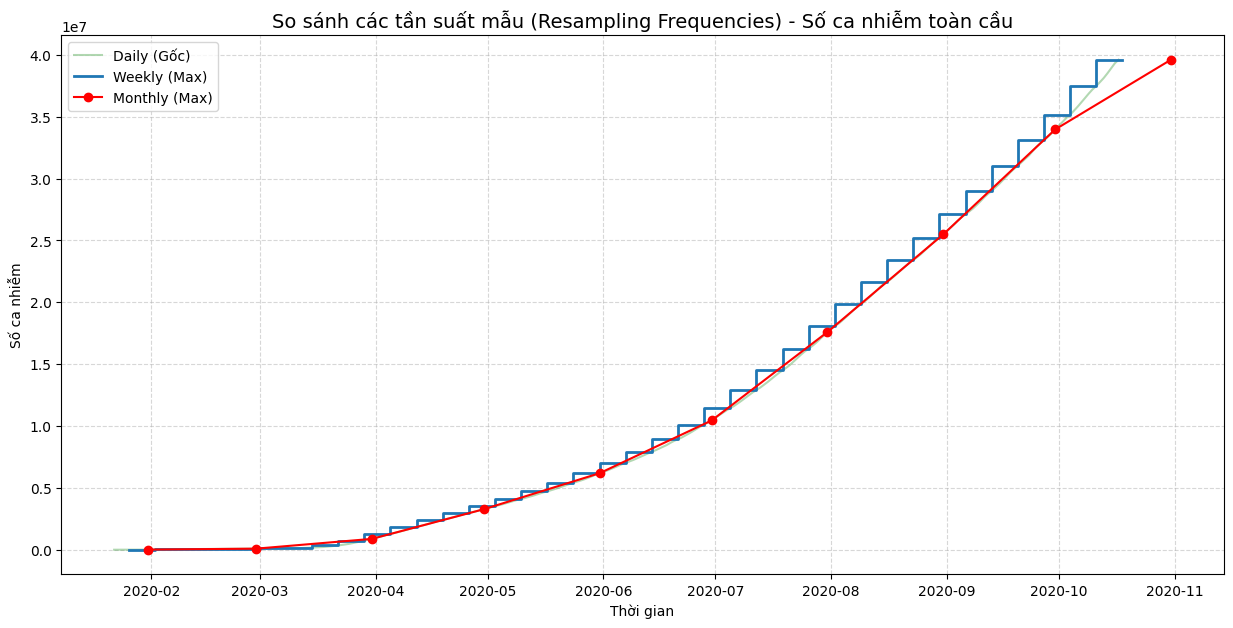

In [14]:
plt.figure(figsize=(15, 7))

plt.plot(global_daily.index, global_daily['Confirmed'], label='Daily (Gốc)', alpha=0.3, color='green')
plt.step(global_weekly.index, global_weekly['Confirmed'], label='Weekly (Max)', linewidth=2)
plt.plot(global_monthly.index, global_monthly['Confirmed'], 'ro-', label='Monthly (Max)')

plt.title("So sánh các tần suất mẫu (Resampling Frequencies) - Số ca nhiễm toàn cầu", fontsize=14)
plt.xlabel("Thời gian")
plt.ylabel("Số ca nhiễm")
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

### Lag Features

In [15]:
# Chọn 1 quốc gia và lấy số ca tích lũy
country_data = df[df['Country/Region'] == 'Afghanistan'].copy()
country_data = country_data.set_index('Date').sort_index()

# 1. Difference Features: Tính số ca nhiễm mới mỗi ngày (Daily New Cases)
# Vì 'Confirmed' là số tích lũy, dùng .diff() để ra số ca mới
country_data['New_Cases'] = country_data['Confirmed'].diff().fillna(0)

In [16]:
# 2. Lag Features: Mang giá trị quá khứ vào hiện tại
# t-1: Ngày hôm qua, t-7: Cùng ngày này tuần trước, t-14: Cách đây 2 tuần
lags = [1, 7, 14]
for lag in lags:
    country_data[f'Lag_{lag}'] = country_data['New_Cases'].shift(lag)

display(country_data[['New_Cases', 'Lag_1', 'Lag_7']].tail())

,New_Cases,Lag_1,Lag_7
Date,,,
2020-10-13,58.0,71.0,64.0
2020-10-14,66.0,58.0,62.0
2020-10-15,32.0,66.0,68.0
2020-10-16,47.0,32.0,77.0
2020-10-17,68.0,47.0,10.0


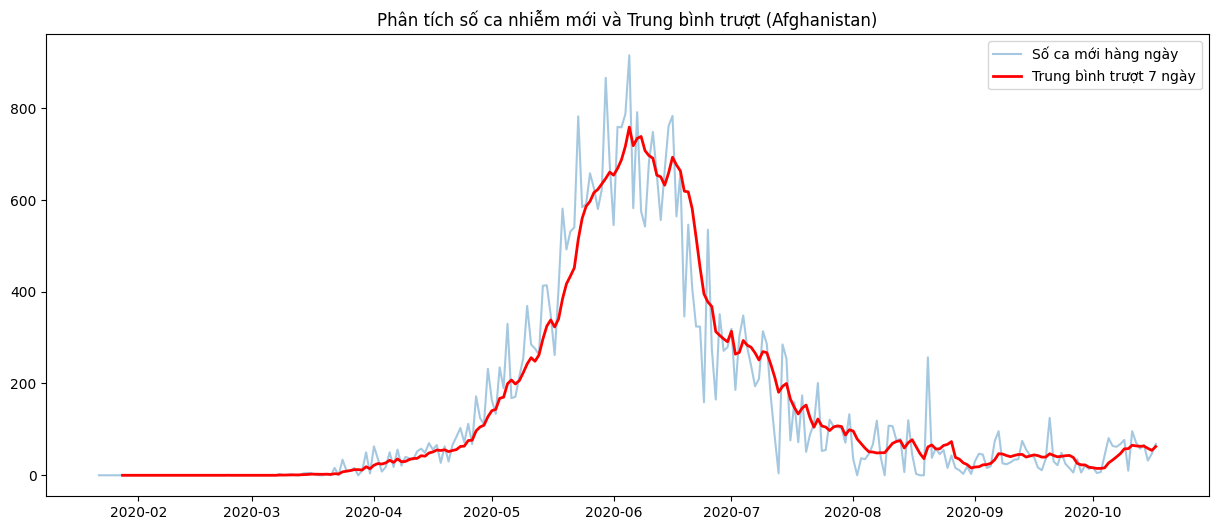

In [17]:
# 3. Rolling Statistics: Trung bình trượt (7 ngày) để làm mượt dữ liệu
window_size = 7
country_data['Rolling_Mean_7'] = country_data['New_Cases'].rolling(window=window_size).mean()
country_data['Rolling_Std_7'] = country_data['New_Cases'].rolling(window=window_size).std()

# Trực quan hóa New Cases vs Rolling Mean
plt.figure(figsize=(15, 6))
plt.plot(country_data['New_Cases'], label='Số ca mới hàng ngày', alpha=0.4)
plt.plot(country_data['Rolling_Mean_7'], label='Trung bình trượt 7 ngày', color='red', linewidth=2)
plt.title("Phân tích số ca nhiễm mới và Trung bình trượt (Afghanistan)")
plt.legend()
plt.show()

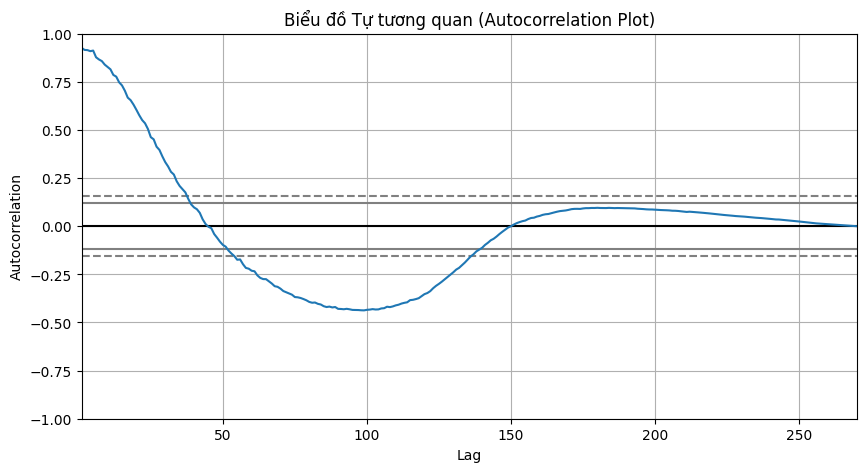

In [18]:
from pandas.plotting import autocorrelation_plot

plt.figure(figsize=(10, 5))
autocorrelation_plot(country_data['New_Cases'])
plt.title("Biểu đồ Tự tương quan (Autocorrelation Plot)")
plt.show()